# **Dataset Cleaning**

source:

GFQA_v2: 
Published November 27, 2024
https://zenodo.org/records/14230628

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data_path = "dataset/GFQA_v2"
output_file = os.path.join(data_path, "GFQA_v2_merged.csv")
param = [
    'pH.csv',
    'Temperature.csv',
    'Electrical_Conductance.csv',
    'Dissolved_Gas.csv',       
    'Oxidized_Nitrogen.csv',   
    'Phosphorus.csv',
    'Optical.csv',            
    'Salinity.csv',
]

# **PH**

In [4]:
ph = pd.read_csv(
    os.path.join(data_path, param[0]),
    sep=';',               
    encoding='ISO-8859-1',
    decimal=',',
    on_bad_lines='skip'
)
ph.drop(columns=['Parameter.Code', 'Unit','Analysis.Method.Code','Value.Flags'], inplace=True)
ph["Value"] = pd.to_numeric(ph["Value"], errors="coerce")

C:\Users\Informatics\AppData\Local\Temp\ipykernel_10564\4229546083.py:1: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  ph = pd.read_csv(


Water pH strongly influences chemical solubility and biological activity. Drinking and surface water standards recommend a near-neutral pH to avoid corrosion, toxicity, and ecosystem stress.

Good (6.5–8.5): Optimal range for aquatic life and human consumption

Estimated (6.0–6.5 or 8.5–9.0): Slight deviation with limited impact

Suspect (5.5–6.0 or 9.0–9.5): Increased biological and chemical risk

Contamination (<5.5 or >9.5): Unsafe due to toxicity or corrosive effects

| Category      | pH Range                         |
| ------------- | -------------------------------- |
| Good          | 6.5 ≤ pH ≤ 8.5                   |
| Estimated     | 6.0 ≤ pH < 6.5 or 8.5 < pH ≤ 9.0 |
| Suspect       | 5.5 ≤ pH < 6.0 or 9.0 < pH ≤ 9.5 |
| Contamination | pH < 5.5 or pH > 9.5             |


In [4]:
def label_ph(v):
    if pd.isna(v):
        return "Unknown"
    elif 6.5 <= v <= 8.5:
        return "Good"
    elif (6.0 <= v < 6.5) or (8.5 < v <= 9.0):
        return "Estimated"
    elif (5.5 <= v < 6.0) or (9.0 < v <= 9.5):
        return "Suspect"
    else:
        return "Contamination"

ph["Data.Quality"] = ph["Value"].apply(label_ph)
print(ph["Data.Quality"].value_counts())

Data.Quality
Good             511552
Estimated         39380
Contamination     10780
Suspect            7800
Name: count, dtype: int64


# **Temperature**

In [6]:
temp = pd.read_csv(
    os.path.join(data_path, param[1]),
    sep=';',                
    encoding='ISO-8859-1',  
    decimal=',',            
    on_bad_lines='skip'
)
temp.drop(columns=['Parameter.Code', 'Unit','Analysis.Method.Code','Value.Flags'], inplace=True)
temp["Value"] = pd.to_numeric(temp["Value"], errors="coerce")

C:\Users\Informatics\AppData\Local\Temp\ipykernel_15756\2239518840.py:1: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(


Water temperature directly affects dissolved oxygen, metabolic rates, and chemical reactions.

Good (0–30 °C): Natural range for freshwater ecosystems

Estimated (−2–0 °C or 30–40 °C): Moderate thermal stress

Suspect (−5–−2 °C or 40–50 °C): Severe biological disturbance

Contamination (outside ranges): Unsuitable for aquatic life

| Category      | Temperature Range (°C)           |
| ------------- | -------------------------------- |
| Good          | 0 ≤ temp ≤ 30                    |
| Estimated     | 30 < temp ≤ 40 or -2 ≤ temp < 0  |
| Suspect       | 40 < temp ≤ 50 or -5 ≤ temp < -2 |
| Contamination | Anything else                    |


In [7]:
def label_temp(v):
    if pd.isna(v):
        return "Unknown"
    elif 0 <= v <= 30:
        return "Good"
    elif (30 < v <= 40) or (-2 <= v < 0):
        return "Estimated"
    elif (40 < v <= 50) or (-5 <= v < -2):
        return "Suspect"
    else:
        return "Contamination"

temp["Data.Quality"] = temp["Value"].apply(label_temp)
print(temp["Data.Quality"].value_counts())

Data.Quality
Good             744960
Estimated         99709
Contamination      2144
Suspect            1231
Name: count, dtype: int64


# **Electrical Conductance**

In [8]:
ec = pd.read_csv(
    os.path.join(data_path, param[2]),
    sep=';',
    encoding='ISO-8859-1',
    decimal=',',
    on_bad_lines='skip'
)
ec.drop(columns=['Parameter.Code', 'Unit','Analysis.Method.Code','Value.Flags'], inplace=True)

C:\Users\Informatics\AppData\Local\Temp\ipykernel_15756\1176802717.py:1: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  ec = pd.read_csv(


Electrical conductivity reflects total dissolved salts and mineralization, serving as a proxy for salinity and pollution.

Good (≤2500 µS/cm): Freshwater with acceptable mineral content

Estimated (2500–3000 µS/cm): Slight salinity increase

Suspect (3000–5000 µS/cm): High ionic concentration

Contamination (>5000 µS/cm): Excessive salinity indicating pollution

| Category      | EC range (μS/cm) |
| ------------- | ---------------- |
| Good          | 0 – 2500         |
| Estimated     | 2500 – 3000      |
| Suspect       | 3000 – 5000      |
| Contamination | >5000            |

In [9]:
def label_ec(v):
    if 0 <= v <= 2500:
        return 'Good'
    elif 2500 < v <= 3000:
        return 'Estimated'
    elif 3000 < v <= 5000:
        return 'Suspect'
    else:
        return 'Contamination'

ec["Value"] = pd.to_numeric(ec["Value"], errors='coerce')
ec["Data.Quality"] = ec["Value"].apply(label_ec)
print(ec["Data.Quality"].value_counts())

Data.Quality
Good             449239
Contamination     22924
Suspect            5366
Estimated          3255
Name: count, dtype: int64


# **Dissolved Gas**

In [10]:
dg = pd.read_csv(
    os.path.join(data_path, param[3]),
    sep=';',
    encoding='ISO-8859-1',
    decimal=',',
    on_bad_lines='skip'
)
dg.drop(columns=['Parameter.Code', 'Unit','Analysis.Method.Code','Value.Flags'], inplace=True)

C:\Users\Informatics\AppData\Local\Temp\ipykernel_15756\4004114844.py:1: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  dg = pd.read_csv(


Dissolved gases, particularly oxygen, are essential for aquatic organisms.

Good (5–15 mg/L): Optimal oxygenation

Estimated (3–5 or 15–18 mg/L): Slight oxygen imbalance

Suspect (1–3 or 18–20 mg/L): Biological stress conditions

Contamination (<1 or >20 mg/L): Hypoxia or gas supersaturation

| Category      | Dissolved Gas (mg/L) |
| ------------- | -------------------- |
| Good          | 5 – 15               |
| Estimated     | 3 – 5 or 15 – 18     |
| Suspect       | 1 – 3 or 18 – 20     |
| Contamination | <1 or >20            |


In [11]:
def label_dg(v):
    if 5 <= v <= 15:
        return 'Good'
    elif 3 <= v < 5 or 15 < v <= 18:
        return 'Estimated'
    elif 1 <= v < 3 or 18 < v <= 20:
        return 'Suspect'
    else:
        return 'Contamination'

dg["Value"] = pd.to_numeric(dg["Value"], errors="coerce")
dg["Data.Quality"] = dg["Value"].apply(label_dg)
print(dg["Data.Quality"].value_counts())

Data.Quality
Good             361568
Contamination    282947
Estimated         42498
Suspect           26515
Name: count, dtype: int64


# **Oxidized itrogen**

In [12]:
oi = pd.read_csv(
    os.path.join(data_path, param[4]),
    sep=';',
    encoding='ISO-8859-1',
    decimal=',',
    on_bad_lines='skip'
)
oi.drop(columns=['Parameter.Code', 'Unit','Analysis.Method.Code','Value.Flags'], inplace=True)

C:\Users\Informatics\AppData\Local\Temp\ipykernel_15756\3589712662.py:1: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  oi = pd.read_csv(


Oxidized nitrogen compounds originate mainly from agricultural runoff and wastewater discharge.

Good (≤10 mg/L): Natural background levels

Estimated (10–20 mg/L): Early anthropogenic influence

Suspect (20–50 mg/L): Risk of eutrophication

Contamination (>50 mg/L): Unsafe for human and ecological health

| Category      | NO₃⁻ + NO₂⁻ (mg/L) |
| ------------- | ------------------ |
| Good          | 0 – 10             |
| Estimated     | 10 – 20            |
| Suspect       | 20 – 50            |
| Contamination | >50                |


In [13]:
def label_oi(v):
    if 0 <= v <= 10:
        return 'Good'
    elif 10 < v <= 20:
        return 'Estimated'
    elif 20 < v <= 50:
        return 'Suspect'
    else:
        return 'Contamination'

oi["Value"] = pd.to_numeric(oi["Value"], errors="coerce")
oi["Data.Quality"] = oi["Value"].apply(label_oi)
print(oi["Data.Quality"].value_counts())

Data.Quality
Good             1005535
Estimated          10999
Suspect             5185
Contamination       2827
Name: count, dtype: int64


# **Phosphorus**

In [14]:
pho = pd.read_csv(
    os.path.join(data_path, param[5]),
    sep=';',
    encoding='ISO-8859-1',
    decimal=',',
    on_bad_lines='skip'
)
pho.drop(columns=['Parameter.Code', 'Unit','Analysis.Method.Code','Value.Flags'], inplace=True)

C:\Users\Informatics\AppData\Local\Temp\ipykernel_15756\919149279.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  pho = pd.read_csv(


Phosphorus is a primary driver of eutrophication in freshwater systems.

Good (≤0.1 mg/L): Low nutrient concentration

Estimated (0.1–0.2 mg/L): Moderate enrichment

Suspect (0.2–0.5 mg/L): High eutrophication risk

Contamination (>0.5 mg/L): Severe algal bloom potential

| Category      | Phosphorus (mg/L) |
| ------------- | ----------------- |
| Good          | 0 – 0.1           |
| Estimated     | 0.1 – 0.2         |
| Suspect       | 0.2 – 0.5         |
| Contamination | >0.5              |


In [15]:
def label_pho(v):
    if 0 <= v <= 0.1:
        return 'Good'
    elif 0.1 < v <= 0.2:
        return 'Estimated'
    elif 0.2 < v <= 0.5:
        return 'Suspect'
    else:
        return 'Contamination'

pho["Value"] = pd.to_numeric(pho["Value"], errors="coerce")
pho["Data.Quality"] = pho["Value"].apply(label_pho)
print(pho["Data.Quality"].value_counts())

Data.Quality
Good             540718
Estimated         95952
Contamination     88281
Suspect           79440
Name: count, dtype: int64


# **Optical**

In [17]:
op = pd.read_csv(
    os.path.join(data_path, param[6]),
    sep=';',
    encoding='ISO-8859-1',
    decimal=',',
    on_bad_lines='skip'
)
op.drop(columns=['Parameter.Code', 'Unit','Analysis.Method.Code','Value.Flags'], inplace=True)

C:\Users\Informatics\AppData\Local\Temp\ipykernel_15756\1335412710.py:1: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  op = pd.read_csv(


Optical measurements indicate suspended particles and water clarity.

Good (≤5 NTU): Clear water

Estimated (5–10 NTU): Slight turbidity

Suspect (10–50 NTU): Reduced light penetration

Contamination (>50 NTU): Highly polluted or sediment-loaded water

| Category      | Turbidity (NTU) |
| ------------- | --------------- |
| Good          | 0 – 5           |
| Estimated     | 5 – 10          |
| Suspect       | 10 – 50         |
| Contamination | >50             |


In [19]:
def label_op(v):
    if 0 <= v <= 5:
        return 'Good'
    elif 5 < v <= 10:
        return 'Estimated'
    elif 10 < v <= 50:
        return 'Suspect'
    else:
        return 'Contamination'

op["Value"] = pd.to_numeric(op["Value"], errors="coerce")
op["Data.Quality"] = op["Value"].apply(label_op)
print(op["Data.Quality"].value_counts())

Data.Quality
Good             262615
Suspect          132736
Contamination    123973
Estimated         46487
Name: count, dtype: int64


# **Salinity**

In [20]:
sa = pd.read_csv(
    os.path.join(data_path, param[7]),
    sep=';',
    encoding='ISO-8859-1',
    decimal=',',
    on_bad_lines='skip'
)
sa.drop(columns=['Parameter.Code', 'Unit','Analysis.Method.Code','Value.Flags'], inplace=True)

Salinity affects water usability and aquatic biodiversity.

Good (≤0.5 g/L): Freshwater

Estimated (0.5–1 g/L): Slight salinization

Suspect (1–3 g/L): Brackish conditions

Contamination (>3 g/L): Unsuitable for freshwater ecosystems

| Category      | Salinity (g/L) |
| ------------- | -------------- |
| Good          | 0 – 0.5        |
| Estimated     | 0.5 – 1        |
| Suspect       | 1 – 3          |
| Contamination | >3             |


In [21]:
def label_sa(v):
    if 0 <= v <= 0.5:
        return 'Good'
    elif 0.5 < v <= 1:
        return 'Estimated'
    elif 1 < v <= 3:
        return 'Suspect'
    else:
        return 'Contamination'

sa["Value"] = pd.to_numeric(sa["Value"], errors="coerce")
sa["Data.Quality"] = sa["Value"].apply(label_sa)
print(sa["Data.Quality"].value_counts())

Data.Quality
Good             775
Contamination    191
Estimated        128
Suspect           46
Name: count, dtype: int64


# **Megring**

Add a parameter name to each CSV

In [22]:
ph['Parameter'] = 'pH'
temp['Parameter'] = 'Temperature'
ec['Parameter'] = 'EC'
sa['Parameter'] = 'Salinity'
dg['Parameter'] = 'Dissolved Gas'
oi['Parameter'] = 'Oxidized Nitrogen'
pho['Parameter'] = 'Phosphorus'
op['Parameter'] = 'Optical'

Concatenate all CSVs (stack)

In [23]:
df_all = pd.concat([ph, temp, ec, sa, dg, oi, pho, op], ignore_index=True)

Pivot so each sample becomes one row

In [24]:
df_pivot = df_all.pivot_table(
    index=['GEMS.Station.Number', 'Sample.Date', 'Sample.Time', 'Depth'],
    columns='Parameter',
    values='Data.Quality',
    aggfunc='first'   # safe because one value per parameter per sample
).reset_index()

Apply worst-case aggregation

In [25]:
severity = {
    'Good': 0,
    'Estimated': 1,
    'Suspect': 2,
    'Contamination': 3
}

Worst quality per sample:

In [26]:
def worst_quality(row):
    vals = row.dropna()
    return max(vals, key=lambda x: severity[x])

df_pivot['Final_Quality'] = df_pivot[
    [c for c in df_pivot.columns if c not in
     ['GEMS.Station.Number','Sample.Date','Sample.Time','Depth']]
].apply(worst_quality, axis=1)

Map to target labels

In [27]:
df_pivot['Target'] = df_pivot['Final_Quality'].apply(
    lambda x: 'good' if x == 'Good' else 'fair'
)

In [28]:
print(df_all.head())

  GEMS.Station.Number Sample.Date Sample.Time Depth  Value Data.Quality  \
0            ARG00003  2018-08-22       10:45  0.25   7.75         Good   
1            ARG00003  2018-11-15       15:47   0.2   7.16         Good   
2            ARG00003  2019-02-21       18:21   0.2   7.56         Good   
3            ARG00003  2019-05-08       15:06  0.18   7.10         Good   
4            ARG00003  2019-11-06       14:10  0.27   7.47         Good   

  Parameter  
0        pH  
1        pH  
2        pH  
3        pH  
4        pH  


In [29]:
print(df_pivot.head())

Parameter GEMS.Station.Number Sample.Date Sample.Time Depth Dissolved Gas  \
0                    ARG00003  2018-08-22       10:45  0.25          Good   
1                    ARG00003  2018-11-15       15:47   0.2       Suspect   
2                    ARG00003  2019-02-21       18:21   0.2          Good   
3                    ARG00003  2019-05-08       15:06  0.18          Good   
4                    ARG00003  2019-08-26       15:55  0.27          Good   

Parameter    EC        Optical Oxidized Nitrogen     Phosphorus Salinity  \
0          Good        Suspect              Good            NaN      NaN   
1          Good  Contamination              Good  Contamination      NaN   
2          Good  Contamination              Good            NaN      NaN   
3          Good  Contamination              Good           Good      NaN   
4          Good  Contamination              Good           Good      NaN   

Parameter Temperature    pH  Final_Quality Target  
0                Good  Good 

Save the results

In [ ]:
# Save the final dataset
df_all.to_csv("final_dataset.csv", index=False)
df_pivot.to_csv("pivot_dataset.csv", index=False)

Although four water quality classes were derived using rule-based thresholds (Good, Estimated, Suspect, Contamination), the final machine-learning target was reduced to a binary representation (good, fair) to maintain consistency with the original GFQA_v2 labeling scheme. The detailed quality classes were preserved to ensure interpretability and traceability of the final predictions.

**Water Quality Index / Threshold-Based Classification**

Water Quality Index (WQI) — widely used in environmental research. In WQI methods, raw parameter values are converted to sub-indices based on threshold ranges and then aggregated into a single quality score for each sample. This is fundamentally a rule-based transformation of raw measurements into quality classes.
https://pmc.ncbi.nlm.nih.gov/articles/PMC10006569

**Modified WQI approaches use parameter thresholds and scoring rules to assess water quality before**

applying machine learning — e.g., Zheng et al. (2024) classify groundwater quality by scoring parameters like pH and conductivity before modeling.<br>
https://www.mdpi.com/2073-4441/16/12/1666

# **Model Training (Detection)**

### **Extra tools**

In [ ]:
import winsound
from plyer import notification

def notify_user(header,message):
    winsound.PlaySound("SystemExit", winsound.SND_ALIAS)
    notification.notify(
        title= header,
        message= message,
        timeout=10
    )

### **Libraries Used**

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

### **Load dataset**

In [ ]:
df_pivot = pd.read_csv("dataset/GFQA_v2/clean/pivot_dataset.csv", low_memory=False)

## **Pre-trainig**

**Map quality strings to numeric**

In [11]:
quality_map = {
    "Good": 1.0,
    "Estimated": 0.75,
    "Suspect": 0.5,
    "Contamination": 0.0
}

quality_columns = ['Dissolved Gas', 'EC', 'Optical', 'Oxidized Nitrogen', 
                   'Phosphorus', 'Salinity', 'Temperature', 'pH']

for col in quality_columns:
    if col in df_pivot.columns:
        df_pivot[col] = df_pivot[col].map(quality_map)

**Handle missing values**

In [13]:
numeric_cols = df_pivot.select_dtypes(include=['float64','int64']).columns
df_pivot[numeric_cols] = df_pivot[numeric_cols].fillna(df_pivot[numeric_cols].mean())
df_pivot = df_pivot.fillna(0)

**Encode target variable**

In [14]:
df_pivot['Target'] = df_pivot['Target'].map({'fair':0, 'good':1})

**Convert Sample.Date to datetime and extract features**

In [15]:
df_pivot['Sample.Date'] = pd.to_datetime(df_pivot['Sample.Date'], errors='coerce')
df_pivot['Year'] = df_pivot['Sample.Date'].dt.year
df_pivot['Month'] = df_pivot['Sample.Date'].dt.month

**Drop unnecessary columns**

In [16]:
df_pivot.drop(['GEMS.Station.Number', 'Sample.Date', 'Sample.Time', 'Final_Quality'], 
              axis=1, inplace=True, errors='ignore')

**Final dataset ready for ML**

In [17]:
print(df_pivot.head())
print("Shape:", df_pivot.shape)

   Depth  Dissolved Gas   EC  Optical  Oxidized Nitrogen  Phosphorus  \
0   0.25            1.0  1.0      0.5                1.0    0.810589   
1   0.20            0.5  1.0      0.0                1.0    0.000000   
2   0.20            1.0  1.0      0.0                1.0    0.810589   
3   0.18            1.0  1.0      0.0                1.0    1.000000   
4   0.27            1.0  1.0      0.0                1.0    1.000000   

   Salinity  Temperature        pH  Target  Year  Month  
0  0.783831          1.0  1.000000       0  2018      8  
1  0.783831          1.0  1.000000       0  2018     11  
2  0.783831          1.0  1.000000       0  2019      2  
3  0.783831          1.0  1.000000       0  2019      5  
4  0.783831          1.0  0.954819       0  2019      8  
Shape: (789370, 12)


**Data split**

In [18]:
df = df_pivot.copy()

X = df.drop('Target', axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## **Random Forest**

In [21]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    max_features='sqrt',
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

bal_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {bal_acc:.6f}")

cv_scores = cross_val_score(rf, X, y, cv=5)
print(f"\nCross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.6f}")

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=importances.values, 
    y=importances.index, 
    hue=importances.index, 
    palette="viridis", 
    legend=False
)
plt.title("Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

notify_user("Training Complete", "The Random Forest model has finished training and evaluation.")

Confusion Matrix:
[[71033     4]
 [    0 86837]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71037
           1       1.00      1.00      1.00     86837

    accuracy                           1.00    157874
   macro avg       1.00      1.00      1.00    157874
weighted avg       1.00      1.00      1.00    157874

Balanced Accuracy: 0.999972

Cross-Validation Scores: [0.99997466 1.         1.         1.         0.99998733]
Mean CV Accuracy: 0.999992


C:\Users\Informatics\AppData\Local\Temp\ipykernel_5132\1319087122.py:40: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



NameError: name 'notify_user' is not defined

In [22]:
model_filename = 'random_forest_model.pkl'
joblib.dump(rf, model_filename)
print(f"Model saved as '{model_filename}'")

Model saved as 'random_forest_model.pkl'


# **Logistic Regression**

Confusion Matrix:
[[56072 14965]
 [14473 72364]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79     71037
           1       0.83      0.83      0.83     86837

    accuracy                           0.81    157874
   macro avg       0.81      0.81      0.81    157874
weighted avg       0.81      0.81      0.81    157874

Balanced Accuracy: 0.811333

CV Balanced Accuracy Scores: [0.73455788 0.67370874 0.8472445  0.76452029 0.68413518]
Mean CV Balanced Accuracy: 0.740833


C:\Users\Informatics\AppData\Local\Temp\ipykernel_19916\3575395980.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


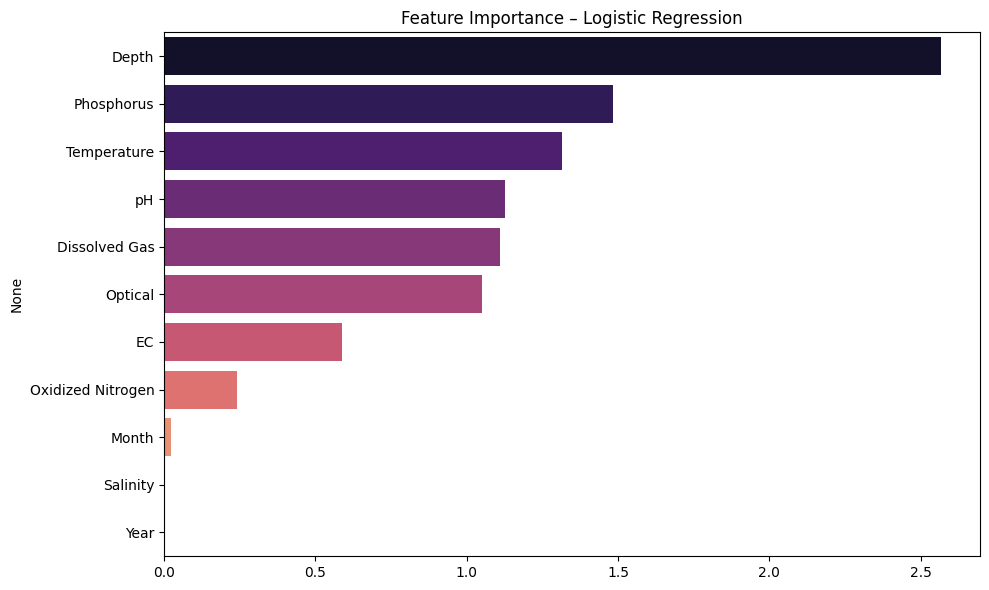

In [15]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    ))
])

# Train
lr_pipeline.fit(X_train, y_train)

# Predict
y_pred_lr = lr_pipeline.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

bal_acc_lr = balanced_accuracy_score(y_test, y_pred_lr)
print(f"Balanced Accuracy: {bal_acc_lr:.6f}")

# Cross-validation
cv_scores_lr = cross_val_score(
    lr_pipeline, X, y, cv=5, scoring="balanced_accuracy"
)

print(f"\nCV Balanced Accuracy Scores: {cv_scores_lr}")
print(f"Mean CV Balanced Accuracy: {cv_scores_lr.mean():.6f}")

coef = lr_pipeline.named_steps["lr"].coef_[0]
importances_lr = pd.Series(np.abs(coef), index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=importances_lr.values,
    y=importances_lr.index,
    palette="magma",
    legend=False
)
plt.title("Feature Importance – Logistic Regression")
plt.tight_layout()
plt.show()

# **Decision Tree**

Confusion Matrix:
[[71037     0]
 [    0 86837]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71037
           1       1.00      1.00      1.00     86837

    accuracy                           1.00    157874
   macro avg       1.00      1.00      1.00    157874
weighted avg       1.00      1.00      1.00    157874

Balanced Accuracy: 1.000000

Cross-Validation Scores: [1. 1. 1. 1. 1.]
Mean CV Accuracy: 1.000000


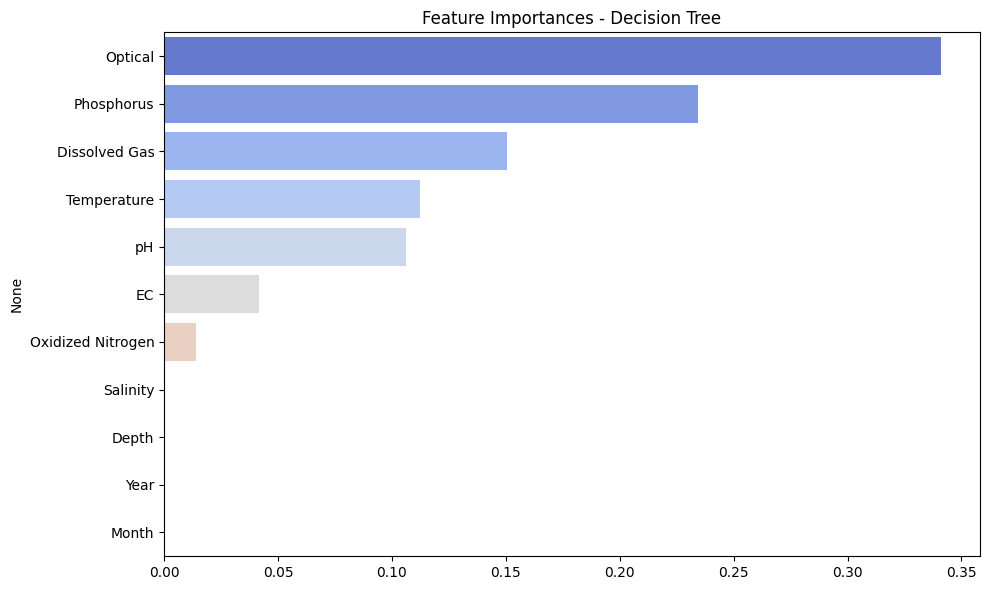

In [18]:
dt = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    class_weight='balanced'
)

# Train
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

bal_acc_dt = balanced_accuracy_score(y_test, y_pred_dt)
print(f"Balanced Accuracy: {bal_acc_dt:.6f}")

cv_scores_dt = cross_val_score(dt, X, y, cv=5)
print(f"\nCross-Validation Scores: {cv_scores_dt}")
print(f"Mean CV Accuracy: {cv_scores_dt.mean():.6f}")

importances_dt = pd.Series(dt.feature_importances_, index=X.columns)
importances_dt = importances_dt.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=importances_dt.values, 
    y=importances_dt.index, 
    hue=importances_dt.index, 
    palette="coolwarm", 
    legend=False
)
plt.title("Feature Importances - Decision Tree")
plt.tight_layout()
plt.show()

# **XGBoost**

Confusion Matrix:
[[71033     4]
 [    0 86837]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71037
           1       1.00      1.00      1.00     86837

    accuracy                           1.00    157874
   macro avg       1.00      1.00      1.00    157874
weighted avg       1.00      1.00      1.00    157874

Balanced Accuracy: 0.999972

Cross-Validation Scores: [0.99997466 1.         1.         1.         0.999981  ]
Mean CV Accuracy: 0.999991


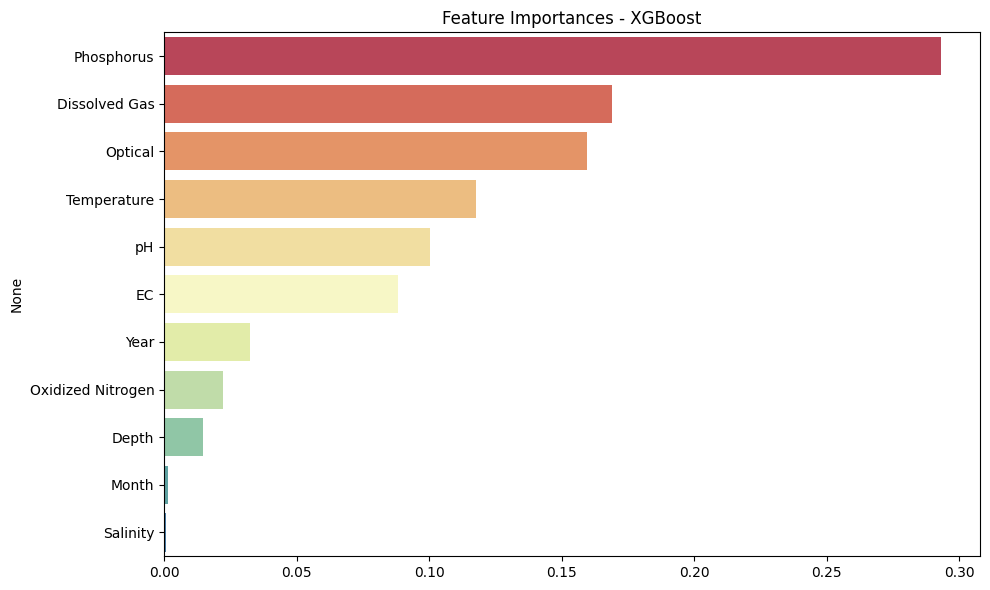

In [26]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Train
xgb_clf.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_clf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

bal_acc_xgb = balanced_accuracy_score(y_test, y_pred_xgb)
print(f"Balanced Accuracy: {bal_acc_xgb:.6f}")

cv_scores_xgb = cross_val_score(xgb_clf, X, y, cv=5)
print(f"\nCross-Validation Scores: {cv_scores_xgb}")

print(f"Mean CV Accuracy: {cv_scores_xgb.mean():.6f}")

importances_xgb = pd.Series(xgb_clf.feature_importances_, index=X.columns)
importances_xgb = importances_xgb.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=importances_xgb.values, 
    y=importances_xgb.index, 
    hue=importances_xgb.index, 
    palette="Spectral", 
    legend=False
)
plt.title("Feature Importances - XGBoost")
plt.tight_layout()
plt.show()

# **LightGBM**

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 347350, number of negative: 284146
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007742 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 236
[LightGBM] [Info] Number of data points in the train set: 631496, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.550043 -> initscore=0.200845
[LightGBM] [Info] Start training from score 0.200845
Confusion Matrix:
[[71037     0]
 [    0 86837]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71037
           1       1.00      1.00      1.00     86837

    accuracy                           1.00    157874
   macro avg       1.00      1.00      1.00    157874
weighted avg     

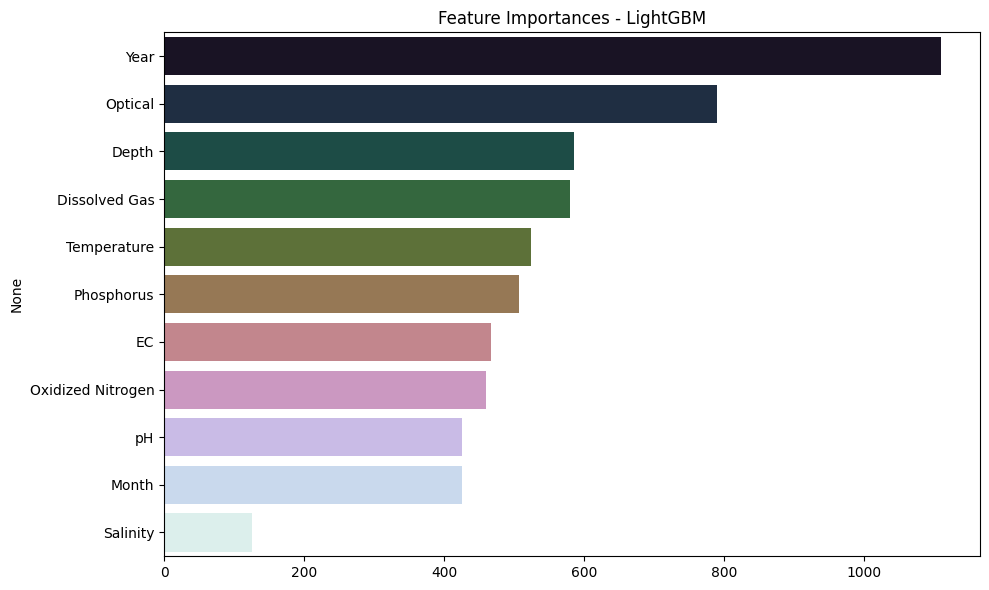

In [11]:
lgb_clf = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=-1,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
# Train
lgb_clf.fit(X_train, y_train)
# Predict
y_pred_lgb = lgb_clf.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgb))
bal_acc_lgb = balanced_accuracy_score(y_test, y_pred_lgb)
print(f"Balanced Accuracy: {bal_acc_lgb:.6f}")
cv_scores_lgb = cross_val_score(lgb_clf, X, y, cv=5)
print(f"\nCross-Validation Scores: {cv_scores_lgb}")
print(f"Mean CV Accuracy: {cv_scores_lgb.mean():.6f}")
importances_lgb = pd.Series(lgb_clf.feature_importances_, index=X.columns)
importances_lgb = importances_lgb.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=importances_lgb.values, 
    y=importances_lgb.index, 
    hue=importances_lgb.index, 
    palette="cubehelix", 
    legend=False
)
plt.title("Feature Importances - LightGBM")
plt.tight_layout()
plt.show()